# DS 6050 Final Project: Deep Learning for American Sign Language Gesture Classification

Erin Siedlecki (ets6dq), Natalie Seah (cva3zw), Bela Barton (rpx2et)

## Intro

This project explores deep learning approaches for American Sign Language (ASL) gesture classification using image-based hand sign data. We compare a custom CNN trained from scratch against transfer learning approaches using EfficientNet-B0 and ResNet18. A major focus of the project was evaluating model generalization and preventing subject-level data leakage through volunteer-based train/test splitting.

## Data Loading

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# When the "[y]es, [n]o, [A]ll, [N]one, [r]ename:" pops up, type N
!cp '/content/drive/MyDrive/DS 6050 - Deep Learning Final Project/Archive/ASL_Raw_Images.zip' /content/
!unzip -q /content/ASL_Raw_Images.zip -d /content/data/
all_data_dir = '/content/data/asl_dataset'  # ← update this path to match your folder name



In [ ]:
import os
import torch
import matplotlib.pyplot as plt
import numpy as np
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
from PIL import Image
from collections import Counter

In [ ]:
SEED = 42

import torch
import numpy as np
import random

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

## Data Preparation

In [ ]:
from torch.utils.data import Dataset, Subset
from torchvision.datasets import ImageFolder
from torchvision import transforms as T
from collections import defaultdict

BATCH_SIZE = 32
img_height = 150
img_width  = 150

IMAGES_PER_VOLUNTEER = 100
NUM_VOLUNTEERS = 10

TRAIN_VOLS = list(range(7))
VAL_VOLS   = [7]
TEST_VOLS  = [8, 9]

dataset_full = ImageFolder(all_data_dir, transform=None)

print(f"Total images:      {len(dataset_full)}")
print(f"Number of classes: {len(dataset_full.classes)}")
print(f"Classes: {dataset_full.classes}")

train_idx, val_idx, test_idx = [], [], []

class_to_indices = defaultdict(list)
for idx, (_, label) in enumerate(dataset_full.samples):
    class_to_indices[label].append(idx)

for label, indices in class_to_indices.items():
    for vol_id in TRAIN_VOLS:
        start = vol_id * IMAGES_PER_VOLUNTEER
        train_idx.extend(indices[start:start + IMAGES_PER_VOLUNTEER])
    for vol_id in VAL_VOLS:
        start = vol_id * IMAGES_PER_VOLUNTEER
        val_idx.extend(indices[start:start + IMAGES_PER_VOLUNTEER])
    for vol_id in TEST_VOLS:
        start = vol_id * IMAGES_PER_VOLUNTEER
        test_idx.extend(indices[start:start + IMAGES_PER_VOLUNTEER])

dataset_train_partial = Subset(dataset_full, train_idx)
dataset_val           = Subset(dataset_full, val_idx)
dataset_test          = Subset(dataset_full, test_idx)

print(f'train: {len(dataset_train_partial)} | val: {len(dataset_val)} | test: {len(dataset_test)}')
# Expected: train: 25200 | val: 3600 | test: 7200

Total images:      36000
Number of classes: 36
Classes: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']
train: 25200 | val: 3600 | test: 7200


In [ ]:
# Check class balance
labels = [label for _, label in dataset_full.samples]
label_counts = Counter(labels)
print("\nImages per class:")
for idx, count in sorted(label_counts.items()):
    print(f"  {dataset_full.classes[idx]}: {count}")


Images per class:
  0: 1000
  1: 1000
  2: 1000
  3: 1000
  4: 1000
  5: 1000
  6: 1000
  7: 1000
  8: 1000
  9: 1000
  A: 1000
  B: 1000
  C: 1000
  D: 1000
  E: 1000
  F: 1000
  G: 1000
  H: 1000
  I: 1000
  J: 1000
  K: 1000
  L: 1000
  M: 1000
  N: 1000
  O: 1000
  P: 1000
  Q: 1000
  R: 1000
  S: 1000
  T: 1000
  U: 1000
  V: 1000
  W: 1000
  X: 1000
  Y: 1000
  Z: 1000


In [ ]:
class TransformData(Dataset):
  def __init__(self, subset, transform):
    self.subset = subset
    self.transform = transform

  def __getitem__(self, idx):
    img, label = self.subset[idx]
    return self.transform(img), label

  def __len__(self):
    return len(self.subset)

In [ ]:
norm_mean = [0.485, 0.456, 0.406]
norm_std = [0.229, 0.224, 0.225]

transform_train = T.Compose([
    T.Resize((img_height, img_width)),
    T.RandomRotation(15),
    T.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    T.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    T.GaussianBlur(kernel_size=3),
    T.RandomGrayscale(p=0.1),
    T.RandomPerspective(distortion_scale=0.3, p=0.5),
    T.RandomHorizontalFlip(p=0.3),
    T.ToTensor(),
    T.Normalize(mean=norm_mean, std=norm_std),
])

transform_val = T.Compose([
    T.Resize((img_height, img_width)),
    T.ToTensor(),
    T.Normalize(mean=norm_mean, std=norm_std),
])

train_dataset = TransformData(dataset_train_partial, transform_train)
val_dataset = TransformData(dataset_val, transform_val)
test_dataset = TransformData(dataset_test, transform_val)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f'train: {len(train_dataset)} |' f'val: {len(val_dataset)} |' f'test: {len(test_dataset)}')

train: 25200 |val: 3600 |test: 7200


## Model 1: Custom CNN

In [ ]:
from torch.nn import Module
import torch.nn as nn
import torch.nn.functional as F

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [ ]:
num_classes = len(dataset_full.classes)

In [ ]:
class MyCNN1(Module):
    def __init__(self, num_classes):
        super().__init__()

        def block(in_channel, out_channel):
          return nn.Sequential(
              nn.Conv2d(in_channel, out_channel, kernel_size=3, padding=1),
              nn.BatchNorm2d(out_channel),
              nn.ReLU(),
              nn.Conv2d(out_channel, out_channel, kernel_size=3, padding=1),
              nn.BatchNorm2d(out_channel),
              nn.ReLU()
          )

        self.block1 = block(3, 32)
        self.block2 = block(32, 64)
        self.block3 = block(64, 128)
        self.block4 = block(128, 256)

        self.pool = nn.MaxPool2d(2)
        self.drop_feat = nn.Dropout(0.25)
        self.gap = nn.AdaptiveAvgPool2d((1,1))

        self.fc1 = nn.Linear(256, 128)
        self.drop_head = nn.Dropout(0.5)
        self.fc2 = nn.Linear (128, num_classes)

    def forward(self, X):
        X = self.pool(self.block1(X)); X = self.drop_feat(X)
        X = self.pool(self.block2(X)); X = self.drop_feat(X)
        X = self.pool(self.block3(X)); X = self.drop_feat(X)
        X = self.pool(self.block4(X)); X = self.drop_feat(X)
        X = self.gap(X)
        X = X.view(X.size(0), -1)
        X = F.relu(self.fc1(X))
        X = self.drop_head(X)
        X = self.fc2(X)
        return X

In [ ]:
loss_fn = nn.CrossEntropyLoss()

def train_loop(dataloader, model, loss_fn, optimizer):
    model.train()
    total_loss = 0
    total_correct = 0
    total_n = 0

    for X, y in dataloader:
        X, y = X.to(device), y.to(device)
        pred = model(X)
        loss = loss_fn(pred, y)

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        total_loss += loss.item() * X.size(0)
        total_correct += (pred.argmax(1)==y).sum().item()
        total_n += X.size(0)
    return total_loss / total_n, total_correct / total_n

@torch.no_grad()
def val_loop(dataloader, model, loss_fn):
    model.eval()
    total_loss = 0
    total_correct = 0
    total_n = 0

    for X, y in dataloader:
      X, y = X.to(device), y.to(device)

      pred = model(X)
      loss = loss_fn(pred, y)

      total_loss += loss.item() * X.size(0)
      total_correct += (pred.argmax(1) == y).sum().item()
      total_n += X.size(0)

    avg_loss = total_loss / total_n
    acc = total_correct / total_n
    return avg_loss, acc

Epoch 1/15 | Training Accuracy 7.0% | Validation Accuracy 24.1% | Validation Loss 2.9879
Epoch 2/15 | Training Accuracy 19.7% | Validation Accuracy 38.6% | Validation Loss 2.1594
Epoch 3/15 | Training Accuracy 33.8% | Validation Accuracy 57.7% | Validation Loss 1.5298
Epoch 4/15 | Training Accuracy 47.1% | Validation Accuracy 64.4% | Validation Loss 1.1969
Epoch 5/15 | Training Accuracy 56.8% | Validation Accuracy 58.3% | Validation Loss 1.0480
Epoch 6/15 | Training Accuracy 63.7% | Validation Accuracy 60.7% | Validation Loss 0.9669
Epoch 7/15 | Training Accuracy 69.7% | Validation Accuracy 66.9% | Validation Loss 0.9198
Epoch 8/15 | Training Accuracy 74.2% | Validation Accuracy 65.7% | Validation Loss 0.9117
Epoch 9/15 | Training Accuracy 78.0% | Validation Accuracy 77.9% | Validation Loss 0.6001
Epoch 10/15 | Training Accuracy 81.5% | Validation Accuracy 77.3% | Validation Loss 0.5640
Epoch 11/15 | Training Accuracy 83.9% | Validation Accuracy 77.9% | Validation Loss 0.4067
Epoch 12/

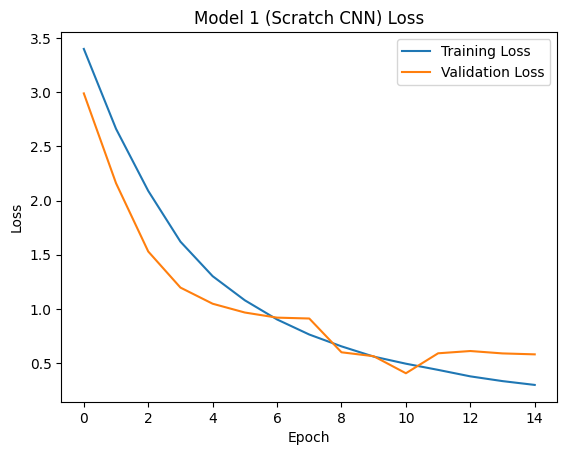

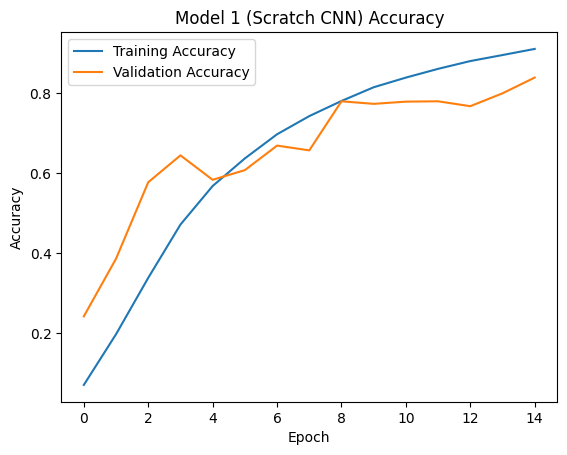

Test Accuracy 77.9% | Test Loss 0.5454


In [ ]:
import matplotlib.pyplot as plt

mod1 = MyCNN1(num_classes=num_classes).to(device)
optimizer = torch.optim.Adam(mod1.parameters(), lr=0.0001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)

epochs = 15
train_losses, train_accs = [], []
val_losses, val_accs = [], []
best_val_acc = 0

for t in range(epochs):
    tr_loss, tr_acc = train_loop(train_loader, mod1, loss_fn, optimizer)
    val_loss, val_acc = val_loop(val_loader, mod1, loss_fn)
    train_losses.append(tr_loss)
    train_accs.append(tr_acc)
    val_losses.append(val_loss)
    val_accs.append(val_acc)
    scheduler.step(val_loss)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(mod1.state_dict(), 'best_model.pt')

    print(f'Epoch {t+1}/{epochs} | Training Accuracy {tr_acc*100:.1f}% | Validation Accuracy {val_acc*100:.1f}% | Validation Loss {val_loss:.4f}')

plt.figure()
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Model 1 (Scratch CNN) Loss')
plt.show()

plt.figure()
plt.plot(train_accs, label='Training Accuracy')
plt.plot(val_accs, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Model 1 (Scratch CNN) Accuracy')
plt.show()

mod1.load_state_dict(torch.load('best_model.pt'))
test_loss, test_acc = val_loop(test_loader, mod1, loss_fn)
print(f'Test Accuracy {test_acc*100:.1f}% | Test Loss {test_loss:.4f}')

In [ ]:
torch.save(mod1.state_dict(), '/content/drive/MyDrive/DS 6050 - Deep Learning Final Project/model1.pt')

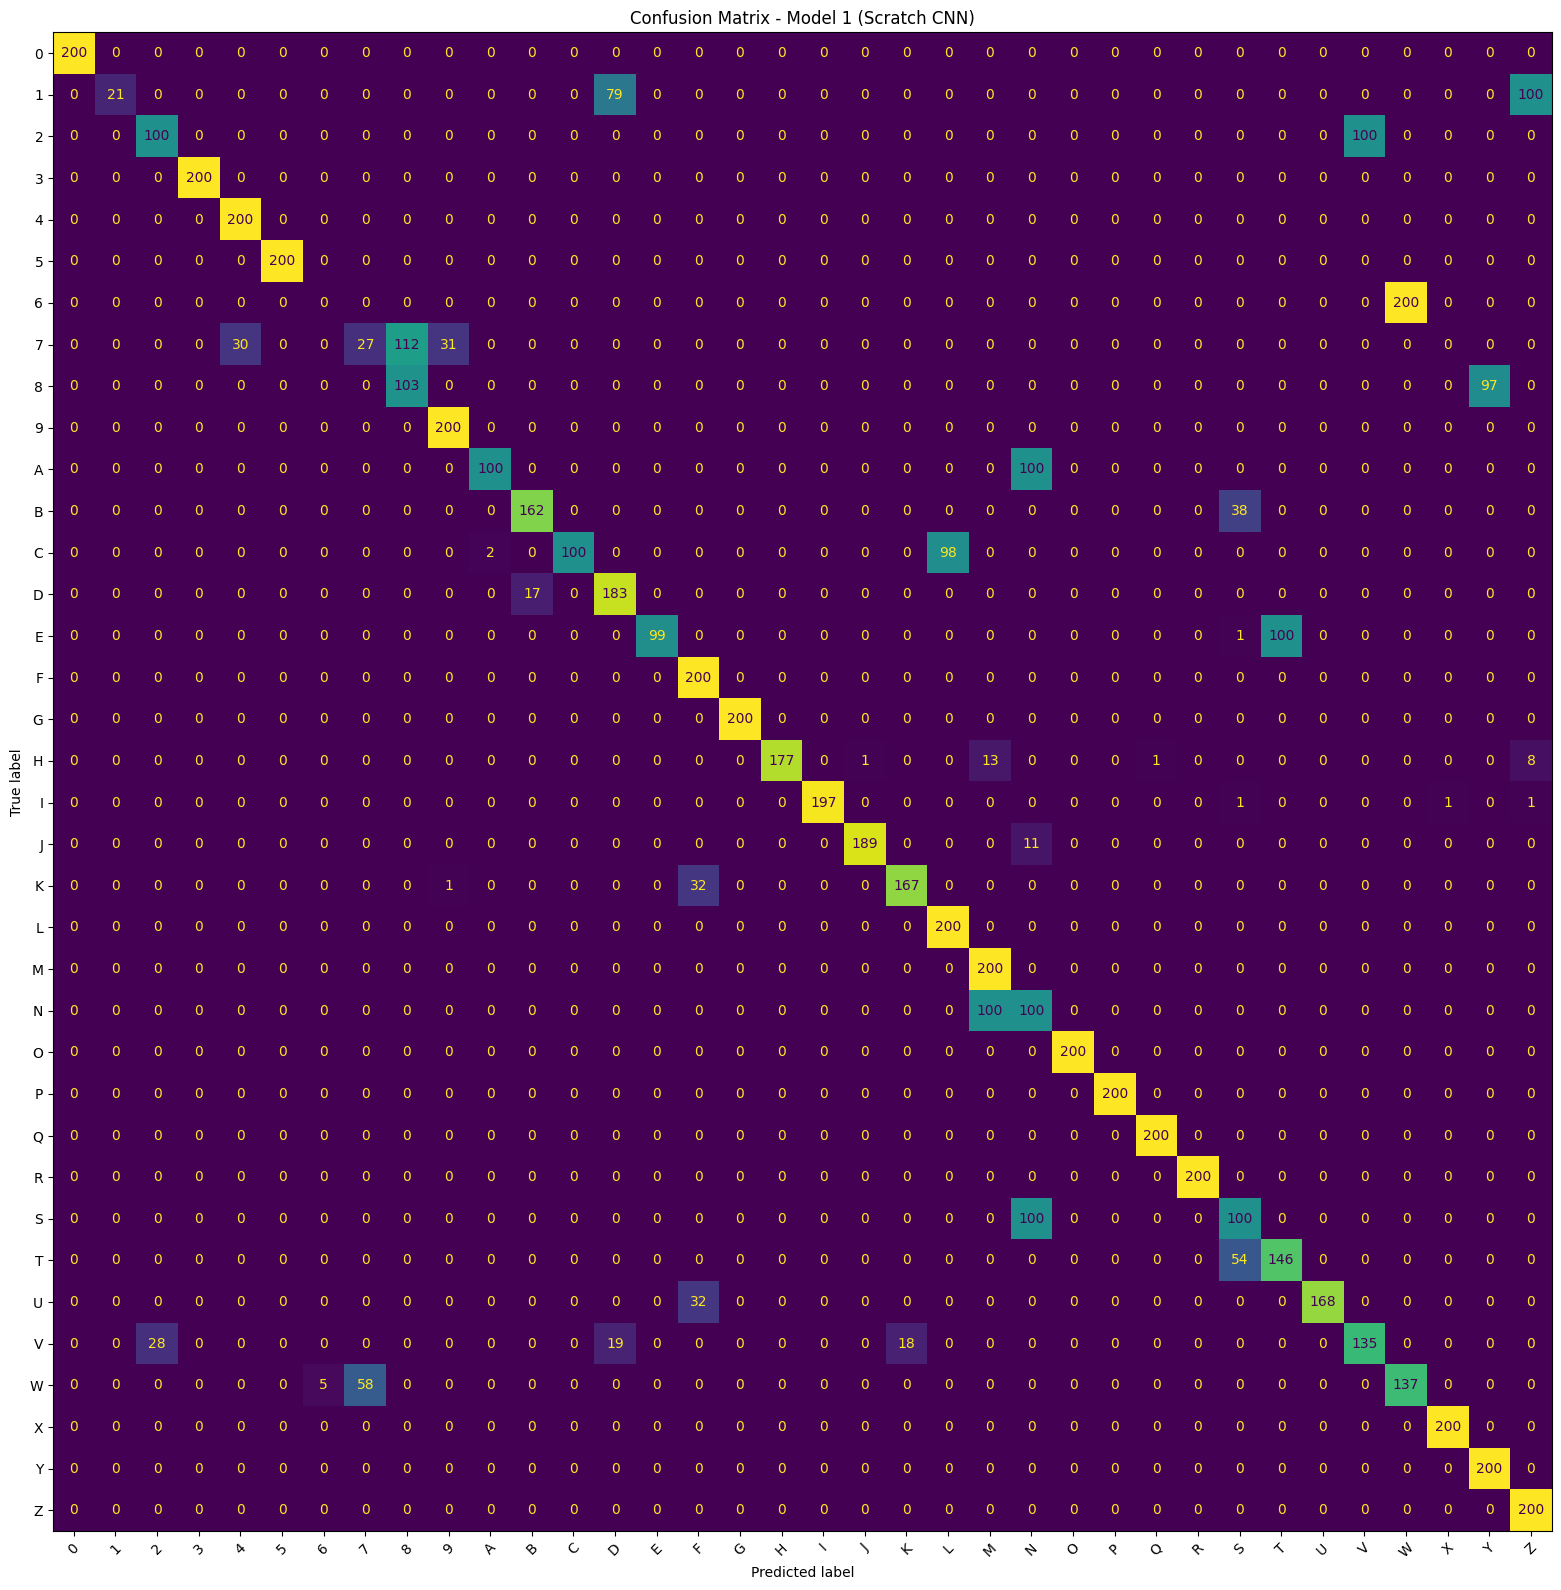

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

all_preds = []
all_labels = []

mod1.eval()
with torch.no_grad():
    for X, y in test_loader:
        X = X.to(device)
        preds = mod1(X).argmax(1).cpu()
        all_preds.extend(preds.tolist())
        all_labels.extend(y.tolist())

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=dataset_full.classes)
fig, ax = plt.subplots(figsize=(16, 16))
disp.plot(ax=ax, xticks_rotation=45, colorbar=False)
plt.title('Confusion Matrix - Model 1 (Scratch CNN)')
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np

cm_interpret1 = cm.copy()
np.fill_diagonal(cm_interpret1, 0)
indices = np.argsort(cm_interpret1.ravel())[::-1]
print('Top confused pairs:')
for idx in indices[:10]:
  i, j = np.unravel_index(idx, cm_interpret1.shape)
  if cm_interpret1[i, j] > 0:
    print(f'{dataset_full.classes[i]} -> {dataset_full.classes[j]}: {cm_interpret1[i, j]}')

Top confused pairs:
6 -> W: 200
7 -> 8: 112
1 -> Z: 100
E -> T: 100
S -> N: 100
A -> N: 100
N -> M: 100
2 -> V: 100
C -> L: 98
8 -> Y: 97


**Interpretation**: Most classes are nearly perfect, but there are certain pairs of signs that look similar that the model has trouble distinguishing. There are more but listed above are some of the notable ones!

## Model 2: EfficientNet-B0

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 158MB/s]


Epoch 1/15 | Training Accuracy 77.1% | Validation Accuracy 86.6% | Validation Loss 0.3885
Epoch 2/15 | Training Accuracy 98.9% | Validation Accuracy 80.6% | Validation Loss 0.5149
Epoch 3/15 | Training Accuracy 99.4% | Validation Accuracy 89.0% | Validation Loss 0.3901
Epoch 4/15 | Training Accuracy 99.6% | Validation Accuracy 86.9% | Validation Loss 0.5050
Epoch 5/15 | Training Accuracy 99.7% | Validation Accuracy 88.1% | Validation Loss 0.3627
Epoch 6/15 | Training Accuracy 99.7% | Validation Accuracy 83.1% | Validation Loss 0.6024
Epoch 7/15 | Training Accuracy 99.7% | Validation Accuracy 82.5% | Validation Loss 0.5638
Epoch 8/15 | Training Accuracy 99.7% | Validation Accuracy 85.2% | Validation Loss 0.7279
Epoch 9/15 | Training Accuracy 99.9% | Validation Accuracy 88.0% | Validation Loss 0.4832
Epoch 10/15 | Training Accuracy 99.9% | Validation Accuracy 86.3% | Validation Loss 0.5118
Epoch 11/15 | Training Accuracy 99.9% | Validation Accuracy 84.1% | Validation Loss 0.7139
Epoch 12

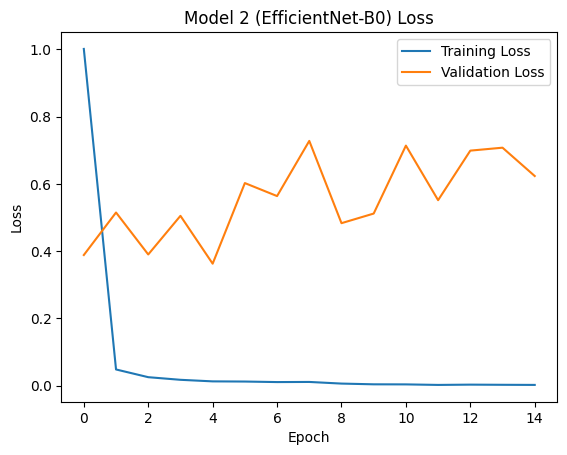

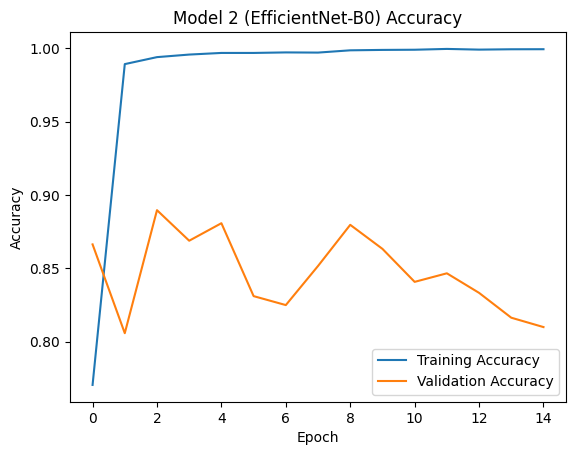

Test Accuracy 84.4% | Test Loss 0.6059


In [ ]:
from torch.nn import Module
from torchvision import models

class MyCNN2(Module):
    def __init__(self, num_classes):
        super().__init__()
        self.model = models.efficientnet_b0(weights='IMAGENET1K_V1')
        self.model.classifier[1] = nn.Linear(1280, num_classes)

    def forward(self, X):
        return self.model(X)

mod2 = MyCNN2(num_classes=num_classes).to(device)
optimizer2 = torch.optim.Adam(mod2.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler2 = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer2, patience=3, factor=0.5)

epochs = 15
best_val_acc2 = 0
train_losses2, train_accs2 = [], []
val_losses2, val_accs2 = [], []

for t in range(epochs):
    tr_loss, tr_acc = train_loop(train_loader, mod2, loss_fn, optimizer2)
    val_loss, val_acc = val_loop(val_loader, mod2, loss_fn)
    train_losses2.append(tr_loss)
    train_accs2.append(tr_acc)
    val_losses2.append(val_loss)
    val_accs2.append(val_acc)
    scheduler2.step(val_loss)

    if val_acc > best_val_acc2:
        best_val_acc2 = val_acc
        torch.save(mod2.state_dict(), 'best_model2.pt')

    print(f'Epoch {t+1}/{epochs} | Training Accuracy {tr_acc*100:.1f}% | Validation Accuracy {val_acc*100:.1f}% | Validation Loss {val_loss:.4f}')

plt.figure()
plt.plot(train_losses2, label='Training Loss')
plt.plot(val_losses2, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Model 2 (EfficientNet-B0) Loss')
plt.show()

plt.figure()
plt.plot(train_accs2, label='Training Accuracy')
plt.plot(val_accs2, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Model 2 (EfficientNet-B0) Accuracy')
plt.show()

mod2.load_state_dict(torch.load('best_model2.pt'))
test_loss2, test_acc2 = val_loop(test_loader, mod2, loss_fn)
print(f'Test Accuracy {test_acc2*100:.1f}% | Test Loss {test_loss2:.4f}')

In [ ]:
torch.save(mod2.state_dict(), '/content/drive/MyDrive/DS 6050 - Deep Learning Final Project/model2.pt')

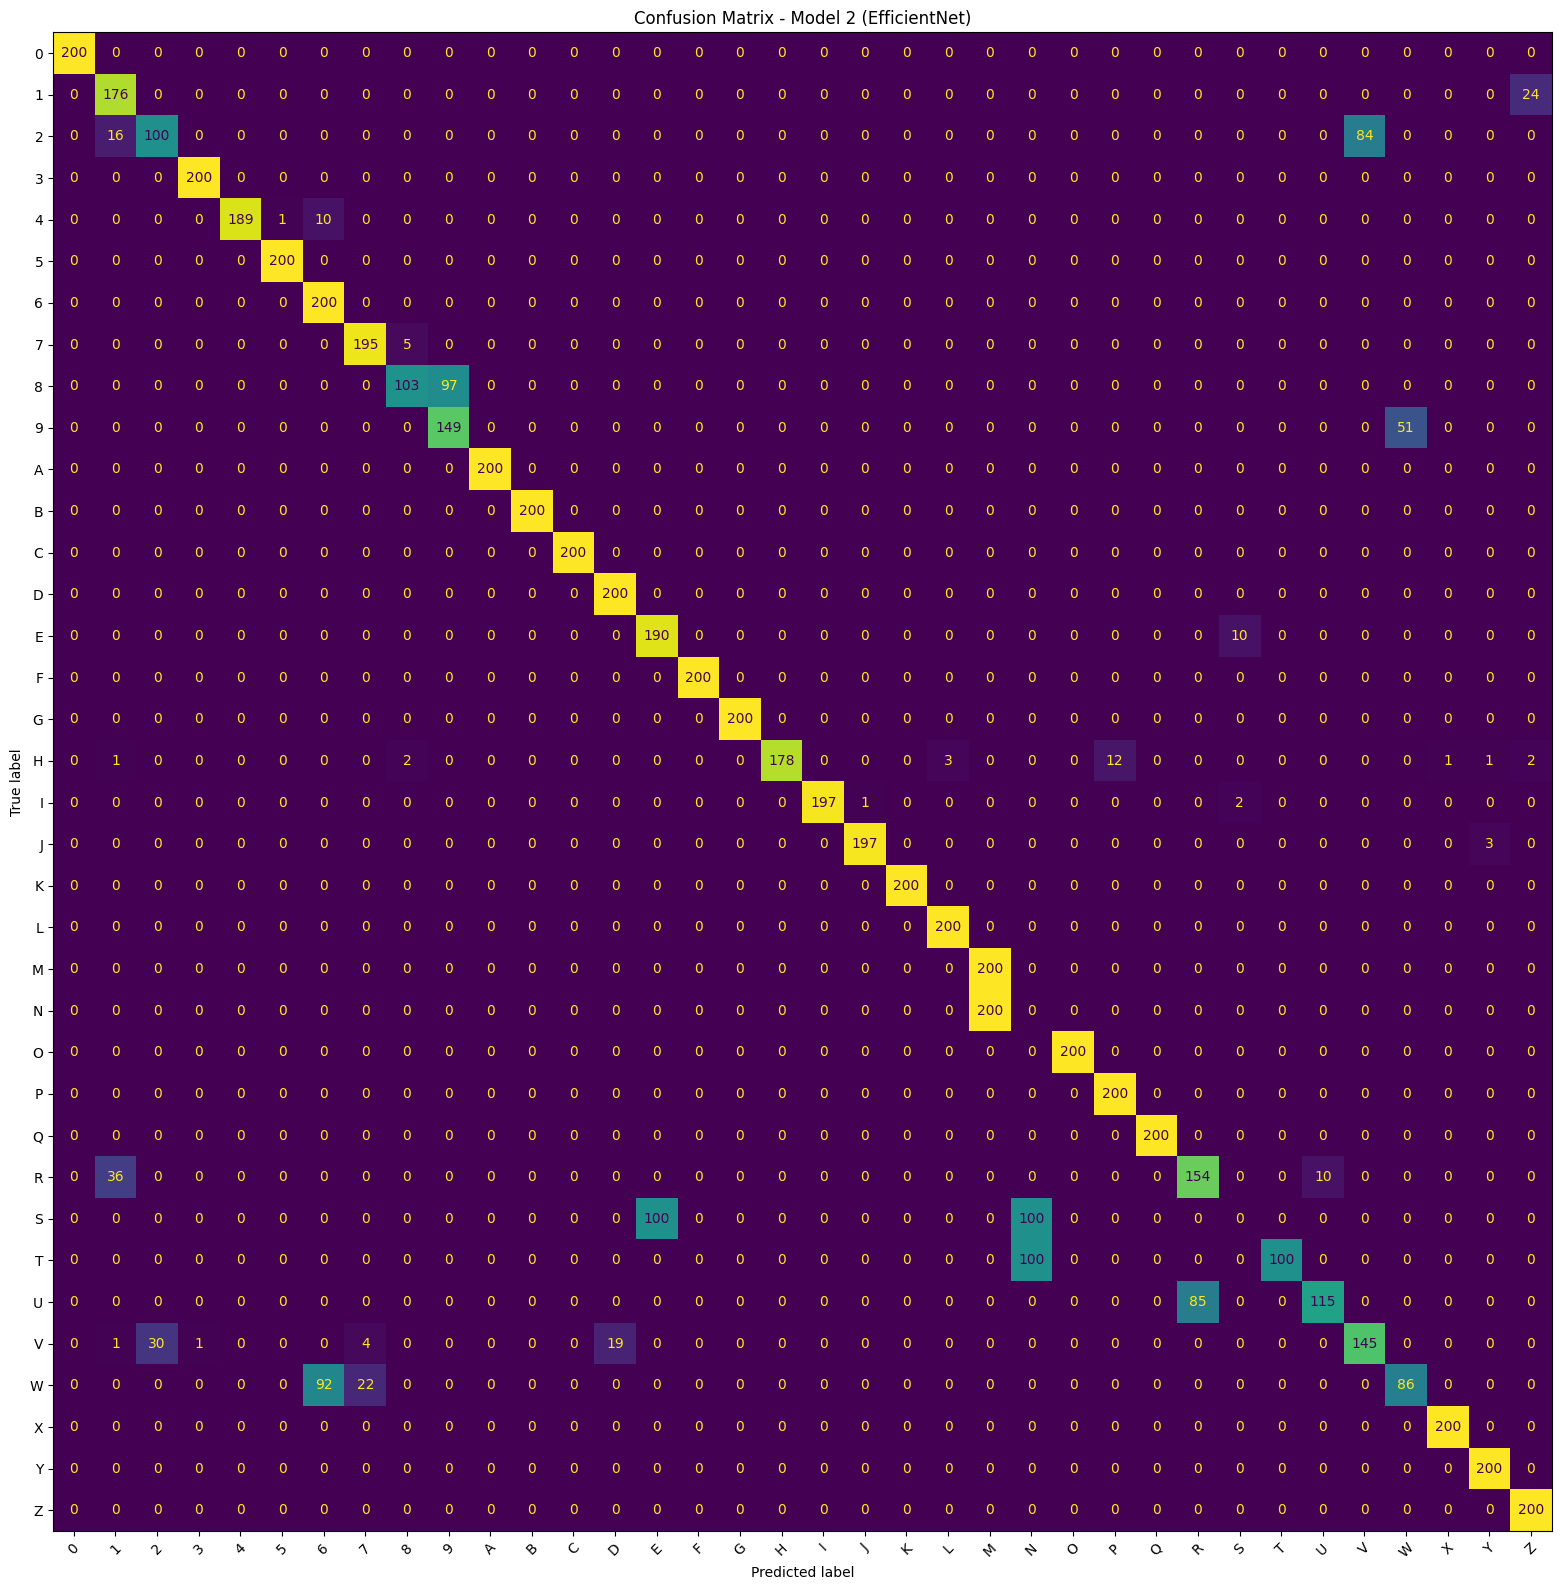

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

all_preds2 = []
all_labels2 = []

mod2.eval()
with torch.no_grad():
    for X, y in test_loader:
        X = X.to(device)
        preds = mod2(X).argmax(1).cpu()
        all_preds2.extend(preds.tolist())
        all_labels2.extend(y.tolist())

cm2 = confusion_matrix(all_labels2, all_preds2)
disp2 = ConfusionMatrixDisplay(cm2, display_labels=dataset_full.classes)
fig, ax = plt.subplots(figsize=(16, 16))
disp2.plot(ax=ax, xticks_rotation=45, colorbar=False)
plt.title('Confusion Matrix - Model 2 (EfficientNet)')
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np

cm_interpret = cm2.copy()
np.fill_diagonal(cm_interpret, 0)
indices = np.argsort(cm_interpret.ravel())[::-1]
print('Top confused pairs:')
for idx in indices[:10]:
  i, j = np.unravel_index(idx, cm_interpret.shape)
  if cm_interpret[i, j] > 0:
    print(f'{dataset_full.classes[i]} -> {dataset_full.classes[j]}: {cm_interpret[i, j]}')

Top confused pairs:
N -> M: 200
T -> N: 100
S -> E: 100
S -> N: 100
8 -> 9: 97
W -> 6: 92
U -> R: 85
2 -> V: 84
9 -> W: 51
R -> 1: 36


## Model 3: ResNet18

In [ ]:
import torchvision.models as models
import torch.nn as nn
from torch.nn import Module

In [ ]:
BATCH_SIZE = 32
img_height = 224
img_width  = 224

norm_mean = [0.485, 0.456, 0.406]
norm_std = [0.229, 0.224, 0.225]

transform_train_res = T.Compose([
    T.Resize((img_height, img_width)),
    T.RandomRotation(15),
    T.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    T.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    T.GaussianBlur(kernel_size=3),
    T.RandomGrayscale(p=0.1),
    T.RandomPerspective(distortion_scale=0.3, p=0.5),
    T.RandomHorizontalFlip(p=0.3),
    T.ToTensor(),
    T.Normalize(mean=norm_mean, std=norm_std),
])

transform_val_res = T.Compose([
    T.Resize((img_height, img_width)),
    T.ToTensor(),
    T.Normalize(mean=norm_mean, std=norm_std),
])

train_dataset_res = TransformData(dataset_train_partial, transform_train_res)
val_dataset_res = TransformData(dataset_val, transform_val_res)
test_dataset_res = TransformData(dataset_test, transform_val_res)

train_loader_res = DataLoader(train_dataset_res, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader_res = DataLoader(val_dataset_res, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader_res = DataLoader(test_dataset_res, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)


In [ ]:
class MyCNN3(Module):
    def __init__(self, n_classes, pretrained=True):
        super().__init__()
        if pretrained:
          self.backbone = models.resnet18(weights = models.ResNet18_Weights.DEFAULT)
        else :
          self.backbone = models.resnet18(weights=None)

        self.backbone.fc = nn.Linear(self.backbone.fc.in_features, n_classes)

    def forward(self, X):
        return self.backbone(X)

In [ ]:
mod3 = MyCNN3(n_classes=num_classes, pretrained=True).to(device)

for p in mod3.parameters():
  p.requires_grad = False

for p in mod3.backbone.layer4.parameters():
  p.requires_grad = True

for p in mod3.backbone.fc.parameters():
  p.requires_grad = True

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 220MB/s]


Epoch 1/10 | Training Accuracy 89.7% | Validation Accuracy 82.2% | Validation Loss 0.7311
Epoch 2/10 | Training Accuracy 99.5% | Validation Accuracy 80.4% | Validation Loss 0.6317
Epoch 3/10 | Training Accuracy 99.7% | Validation Accuracy 81.4% | Validation Loss 0.5865
Epoch 4/10 | Training Accuracy 99.7% | Validation Accuracy 85.0% | Validation Loss 0.5127
Epoch 5/10 | Training Accuracy 99.6% | Validation Accuracy 79.1% | Validation Loss 0.9348
Epoch 6/10 | Training Accuracy 99.8% | Validation Accuracy 82.8% | Validation Loss 0.6977
Epoch 7/10 | Training Accuracy 99.6% | Validation Accuracy 78.6% | Validation Loss 0.7320
Epoch 8/10 | Training Accuracy 100.0% | Validation Accuracy 79.4% | Validation Loss 0.8788
Epoch 9/10 | Training Accuracy 99.9% | Validation Accuracy 81.4% | Validation Loss 0.7834
Epoch 10/10 | Training Accuracy 99.9% | Validation Accuracy 81.4% | Validation Loss 0.7918


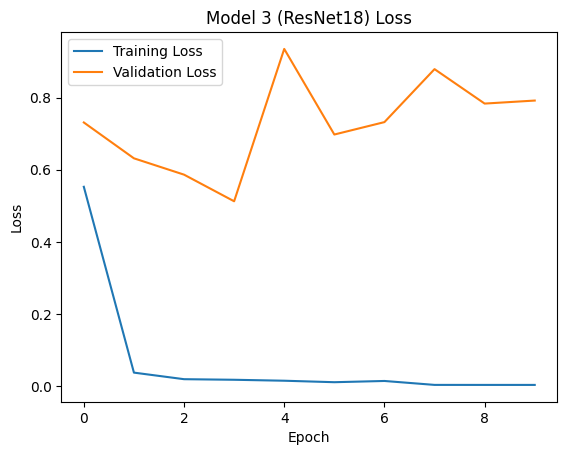

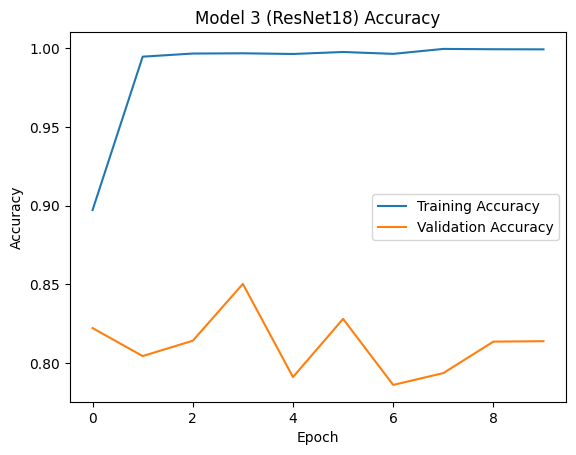

In [ ]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, mod3.parameters()), lr=0.0001, weight_decay=0.0001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=2, factor=0.5)

epochs = 10
train_losses3, train_accs3 = [], []
val_losses3, val_accs3 = [], []
best_val_acc3 = 0

for t in range(epochs):
  tr_loss3, tr_acc3 = train_loop(train_loader_res, mod3, loss_fn, optimizer)
  val_loss3, val_acc3 = val_loop(val_loader_res, mod3, loss_fn)
  train_losses3.append(tr_loss3)
  train_accs3.append(tr_acc3)
  val_losses3.append(val_loss3)
  val_accs3.append(val_acc3)

  scheduler.step(val_loss3)

  if val_acc3 > best_val_acc3:
    best_val_acc3 = val_acc3
    torch.save(mod3.state_dict(), 'best_resnet18_regularized.pt')

  print(f'Epoch {t+1}/{epochs} | Training Accuracy {tr_acc3*100:.1f}% | Validation Accuracy {val_acc3*100:.1f}% | Validation Loss {val_loss3:.4f}')

plt.figure()
plt.plot(train_losses3, label='Training Loss')
plt.plot(val_losses3, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Model 3 (ResNet18) Loss')
plt.show()

plt.figure()
plt.plot(train_accs3, label='Training Accuracy')
plt.plot(val_accs3, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Model 3 (ResNet18) Accuracy')
plt.show()

In [ ]:
mod3.load_state_dict(torch.load('best_resnet18_regularized.pt'))
test_loss3, test_acc3 = val_loop(test_loader_res, mod3, loss_fn)
print(f'Test Accuracy {test_acc3*100:.1f}% | Test Loss {test_loss3:.4f}')

Test Accuracy 81.2% | Test Loss 0.6355


In [ ]:
torch.save(mod3.state_dict(), '/content/drive/MyDrive/DS 6050 - Deep Learning Final Project/model3.pt')

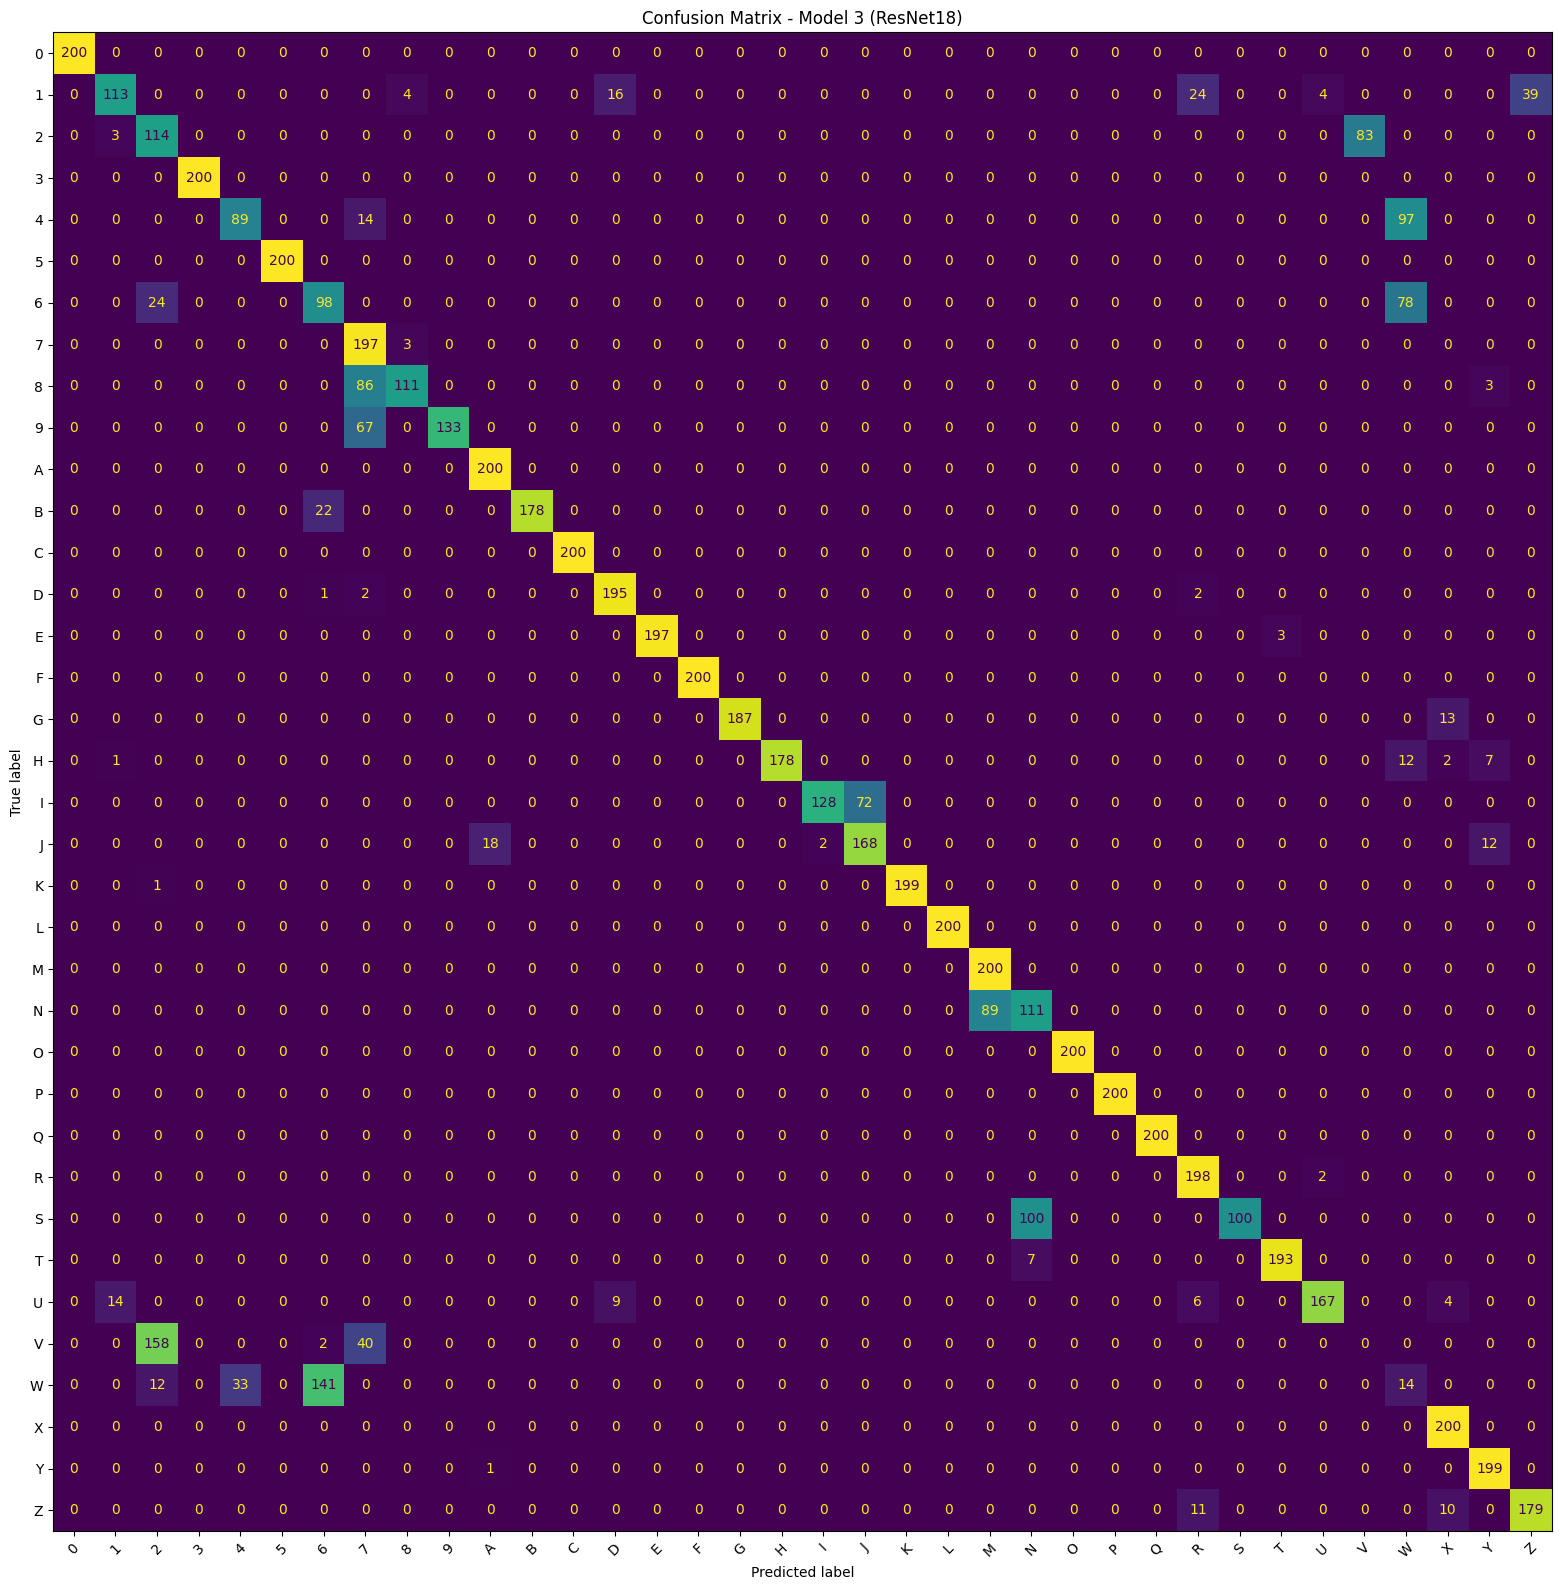

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

all_preds3 = []
all_labels3 = []

mod3.eval()
with torch.no_grad():
    for X, y in test_loader_res:
        X = X.to(device)
        preds = mod3(X).argmax(1).cpu()
        all_preds3.extend(preds.tolist())
        all_labels3.extend(y.tolist())

cm3 = confusion_matrix(all_labels3, all_preds3)
disp3 = ConfusionMatrixDisplay(cm3, display_labels=dataset_full.classes)
fig, ax = plt.subplots(figsize=(16, 16))
disp3.plot(ax=ax, xticks_rotation=45, colorbar=False)
plt.title('Confusion Matrix - Model 3 (ResNet18)')
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np

cm_interpret = cm3.copy()
np.fill_diagonal(cm_interpret, 0)
indices = np.argsort(cm_interpret.ravel())[::-1]
print('Top confused pairs:')
for idx in indices[:10]:
  i, j = np.unravel_index(idx, cm_interpret.shape)
  if cm_interpret[i, j] > 0:
    print(f'{dataset_full.classes[i]} -> {dataset_full.classes[j]}: {cm_interpret[i, j]}')

Top confused pairs:
V -> 2: 158
W -> 6: 141
S -> N: 100
4 -> W: 97
N -> M: 89
8 -> 7: 86
2 -> V: 83
6 -> W: 78
I -> J: 72
9 -> 7: 67


**Interpretation:**
While the model performs well, some of the classes are still confused because their signs are similar, making it challenging for the model to distinguish subtle differences. The top most commonly misclassified pairs are listed above.

## Model Comparison

In [ ]:
import pandas as pd

model1_results = {
    'train_acc': train_accs[-1] * 100,
    'val_acc': max(val_accs) * 100,
    'test_acc': test_acc * 100,
    'test_loss': test_loss
}

model2_results = {
    'train_acc': train_accs2[-1] * 100,
    'val_acc': max(val_accs2) * 100,
    'test_acc': test_acc2 * 100,
    'test_loss': test_loss2
}

model3_results = {
    'train_acc': train_accs3[-1] * 100,
    'val_acc': max(val_accs3) * 100,
    'test_acc': test_acc3 * 100,
    'test_loss': test_loss3
}

results = pd.DataFrame({
    'Model': ['Model 1: Scratch CNN', 'Model 2: EfficientNet', 'Model 3: ResNet18'],
    'Train Accuracy': [model1_results['train_acc'], model2_results['train_acc'], model3_results['train_acc']],
    'Best Validation Accuracy': [model1_results['val_acc'], model2_results['val_acc'], model3_results['val_acc']],
    'Test Accuracy': [model1_results['test_acc'], model2_results['test_acc'], model3_results['test_acc']],
    'Test Loss': [model1_results['test_loss'], model2_results['test_loss'], model3_results['test_loss']]
})
print("Model Comparison Summary:")
display(results.style.format({
    'Train Accuracy': '{:.2f}',
    'Best Validation Accuracy': '{:.2f}',
    'Test Accuracy': '{:.2f}',
    'Test Loss': '{:.4f}'
    }, na_rep='').hide(axis='index'))

Model Comparison Summary:


Model,Train Accuracy,Best Validation Accuracy,Test Accuracy,Test Loss
Model 1: Scratch CNN,91.05,83.89,77.93,0.5454
Model 2: EfficientNet,99.95,88.97,84.36,0.6059
Model 3: ResNet18,99.92,85.03,81.19,0.6355


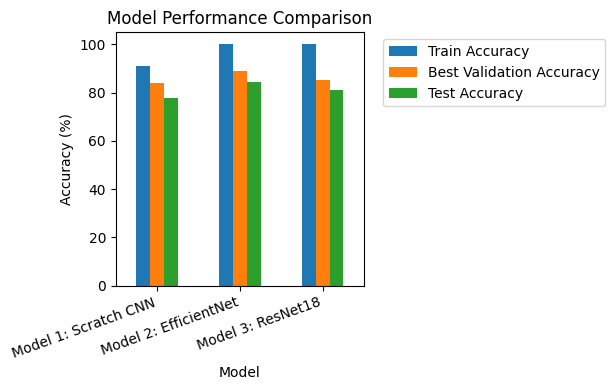

In [ ]:
acc_df = results.set_index('Model')[['Train Accuracy', 'Best Validation Accuracy', 'Test Accuracy']]
ax = acc_df.plot(kind='bar', figsize=(6,4))
plt.title('Model Performance Comparison')
plt.ylabel('Accuracy (%)')
plt.xticks(rotation=20, ha='right')
plt.legend(title='', bbox_to_anchor=(1.05,1), loc='upper left')
plt.tight_layout()
plt.show()

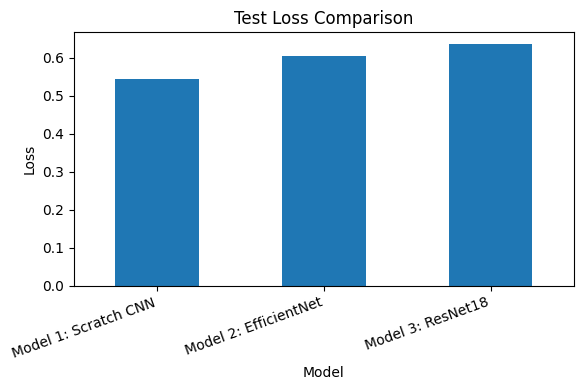

In [ ]:
loss_df = results.set_index('Model')[['Test Loss']]
ax = loss_df.plot(kind='bar', figsize=(6,4), legend=False)
plt.title('Test Loss Comparison')
plt.ylabel('Loss')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

**AI USE NOTE**

We used AI tools to support our workflow by helping us work through challenges, clarify complex concepts, and refine portions of our code. These tools served as a guide when we encountered obstacles and needed additional direction.